# EX 5: Medical Insurance Prediction

**Objective**: Learn more about Linear Regression and its different training techniques.
    
You will be using a medical insurance dataset.
Below are some informations to help **frame the problem**:

For a health insurance company to make money, it needs to collect more in yearly premiums than it spends on medical care to its beneﬁciaries.

As a result, insurers invest a great deal of time and money in developing models that accurately forecast medical expenses for the insured population.

Medical expenses are diﬃcult to estimate because the costliest conditions are rare and seemingly random.

Still, some conditions are more prevalent for certain segments of the population. For instance, lung cancer is more likely among smokers than non-smokers, and heart disease may be more likely among the obese.

The goal of this analysis is to use patient data to estimate the average medical care expenses for such population segments.

These estimates can be used to create actuarial tables that set the price of yearly premiums higher or lower, depending on the expected treatment costs.


## Collecting data

For this analysis, we will use a simulated dataset containing hypothetical medical expenses for patients in the United States.

This data was created using demographic statistics from the US Census Bureau, and approximately reﬂect real-world conditions.

The data includes **1,338 examples** of beneﬁciaries currently enrolled in the insurance plan, with features indicating characteristics of the patient as well as the total medical expenses charged to the plan for the calendar year. There are 6 features:

    • age: An integer indicating the age of the primary beneﬁciary (excluding those above 64 years, since they are generally covered by the government).

    • sex: The policy holder’s gender, either male or female.

    • bmi: The body mass index (BMI), which provides a sense of how over- or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.

    • children: An integer indicating the number of children/dependents covered by the insurance plan.

    • smoker: A yes or no categorical variable that indicates whether the insured regularly smokes tobacco.

    • region: The beneﬁciary’s place of residence in the US,divided into four geographic regions: northeast, southeast, southwest, or northwest.

It is important to give some thought to how these variables may be related to billed medical expenses.

For instance, we might expect that older people and smokers are at higher risk of large medical expenses. Unlike many other machine learning methods, in regression analysis, the relationships among the features are typically speciﬁed by the user rather than being detected automatically.

Let’s explore some of these potential relationships.


## Exploring and preparing the data

1. Load the data for analysis.
2. Show the structure of the data.
3. What feature is the dependent feature and which ones are the independent features? What is the type of each feature in the data?
4. How to analysis the dependent feature and why using this method?
5. Give two methods that describe if the dependent variable is normally distributed? Explain the distribution of the dependent feature.
6. Which of the independent features are categoricals in the data? Look into the distribution of each one. Explain the results.


In [22]:
# 1) Load the data for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
DIRECT_PATH = Path("D:/CPSC-5310-Machine_Learning/Machine_Learning/Week_4/ex5/insurance-2.csv")
DATA_PATH = Path("insurance-2.csv")
df = pd.read_csv(DIRECT_PATH)

df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
# 2) Show the structure of the data
print("Shape (rows, cols):", df.shape)
display(df.sample(5, random_state=42))

df.info()


Shape (rows, cols): (1338, 7)


,age,sex,bmi,children,smoker,region,charges
764,45,female,25.175,2,no,northeast,9095.06825
887,36,female,30.020,0,no,northwest,5272.17580
890,64,female,26.885,0,yes,northwest,29330.98315
1293,46,male,25.745,3,no,northwest,9301.89355
259,19,male,31.920,0,yes,northwest,33750.29180


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [24]:
# 3) What feature is the dependent feature and which ones are the independent features? What is the type of each feature in the data?
target = "charges"
X_cols = [c for c in df.columns if c != target]

print("Dependent (target):", target)
print("Independent (features):", X_cols)
 
types = df.dtypes.to_frame("dtype")
types["role"] = ["dependent" if c == target else "independent" for c in types.index]
types


Dependent (target): charges
Independent (features): ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


,dtype,role
age,int64,independent
sex,object,independent
bmi,float64,independent
children,int64,independent
smoker,object,independent
region,object,independent
charges,float64,dependent


### Step 3 — What feature is the dependent feature and which ones are the independent features? What is the type of each feature in the data?

- Dependent (target) feature: `charges` (numeric, continuous → regression target).
- Independent (input) features: `age`, `sex`, `bmi`, `children`, `smoker`, `region`.



count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Skewness: 1.5158796580240388
Kurtosis: 1.6062986532967907


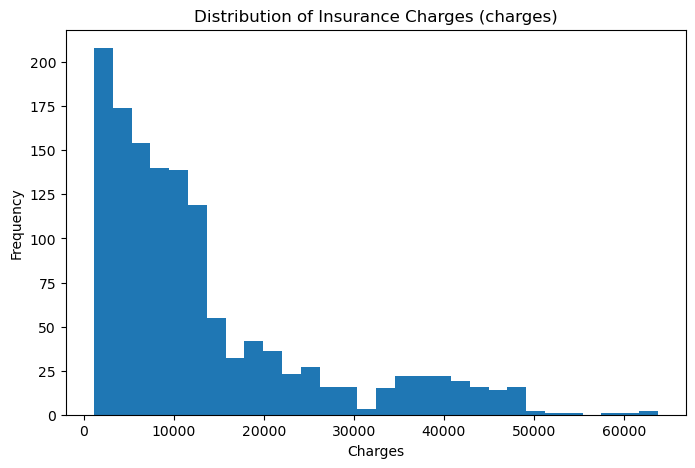

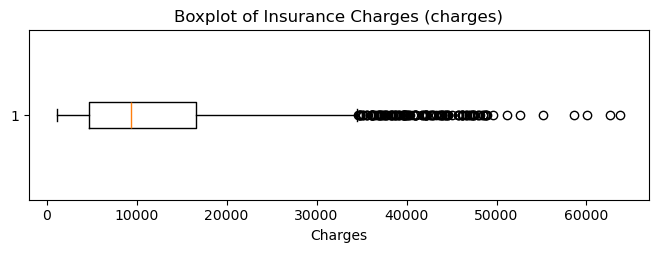

In [25]:
# 4) How to analysis the dependent feature and why using this method?
charges = df[target]

summary = charges.describe()
skew = charges.skew()
kurt = charges.kurtosis()

display(summary)
print("Skewness:", skew)
print("Kurtosis:", kurt)

plt.figure(figsize=(8, 5))
plt.hist(charges, bins=30)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges (charges)")
plt.show()

plt.figure(figsize=(8, 2.2))
plt.boxplot(charges, vert=False)
plt.xlabel("Charges")
plt.title("Boxplot of Insurance Charges (charges)")
plt.show()


### Step 4 — How to analysis the dependent feature and why using this method?

Because `charges` is continuous numeric, we analyze it with descriptive statistics and distribution plots (histogram + boxplot) to understand:
- center/spread (mean, median, quartiles),
- skewness/outliers (important for regression).

What we see from the output:
- Mean ≈ 13270.42, median ≈ 9382.03
- Min ≈ 1121.87, max ≈ 63770.43
- Skewness ≈ 1.516 (right-skewed)
- Boxplot shows high-charge outliers, which can influence a linear regression fit.


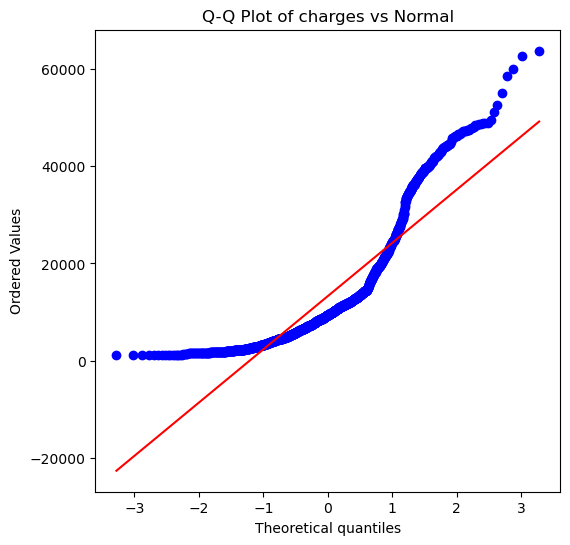

D'Agostino K^2 statistic: 336.8851220567733
p-value: 7.019807901276197e-74

Shapiro-Wilk (sample) statistic: 0.8146881157362379
p-value: 1.1505226334930885e-36


In [26]:
# 5) Two methods to assess normality of the dependent feature
import scipy.stats as stats

# Method A: Q-Q plot
plt.figure(figsize=(6, 6))
stats.probplot(charges, dist="norm", plot=plt)
plt.title("Q-Q Plot of charges vs Normal")
plt.show()

# Method B: Normality test (D'Agostino's K^2) - good for moderate/large samples
k2_stat, k2_p = stats.normaltest(charges)
print("D'Agostino K^2 statistic:", k2_stat)
print("p-value:", k2_p)

# Optional: Shapiro-Wilk on a sample (recommended if dataset is large)
sample = charges.sample(n=min(len(charges), 5000), random_state=42)
sh_stat, sh_p = stats.shapiro(sample)
print("\nShapiro-Wilk (sample) statistic:", sh_stat)
print("p-value:", sh_p)


### Step 5 — Give two methods that describe if the dependent variable is normally distributed? Explain the distribution of the dependent feature.

Two common ways to assess whether `charges` is normally distributed:

1. Q–Q plot: if points follow the diagonal line, the data is close to normal.
2. Normality test (e.g., D’Agostino’s K² or Shapiro–Wilk): small p-value → reject normality.

Because both p-values are extremely small, we reject normality.  
The histogram + Q–Q plot show `charges` is right-skewed with a long high-cost tail (outliers).


Categorical independent features: ['sex', 'smoker', 'region']
Numeric independent features: ['age', 'bmi', 'children']


,count
sex,
male,676
female,662


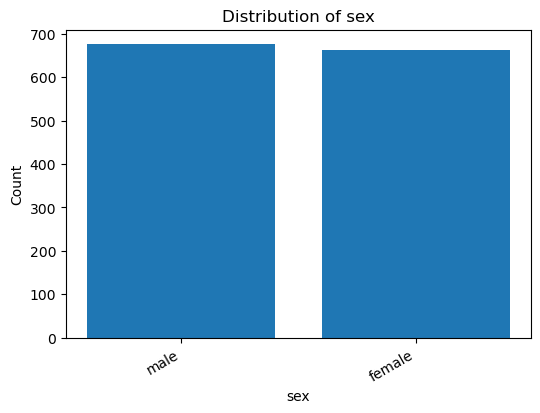

,count
smoker,
no,1064
yes,274


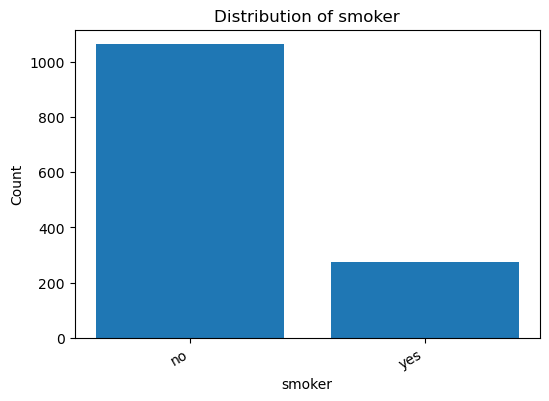

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


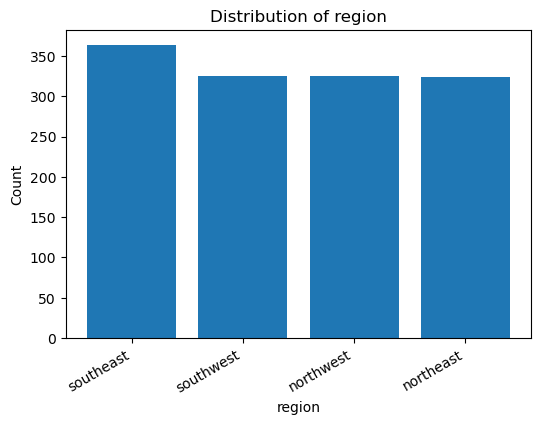

In [27]:
# 6) Which of the independent features are categoricals in the data? Look into the distribution of each one. Explain the results.
categorical_cols = [c for c in X_cols if df[c].dtype == "object"]
numeric_cols = [c for c in X_cols if c not in categorical_cols]

print("Categorical independent features:", categorical_cols)
print("Numeric independent features:", numeric_cols)

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    display(counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30, ha="right")
    plt.show()


### Step 6 — Which of the independent features are categoricals in the data? Look into the distribution of each one. Explain the results.

Categorical independent features in this dataset are:
- `sex` (male/female)
- `smoker` (yes/no)
- `region` (northeast/northwest/southeast/southwest)

the dataset is balanced for `sex` and `region`, but imbalanced for `smoker`.


## Exploring relationships among features

Before ﬁtting a regression model to data, it can be useful to determine how the independent variables are related to the dependent variable and each other.

A correlation matrix provides a quick overview of these relationships.Given a set of variables, it provides a correlation for each pairwise relationship.

   7. Create a correlation matrix for the four numeric variables in the insurance data frame.
   
   8. Is there any interesting relationship between features? Explain those associations


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


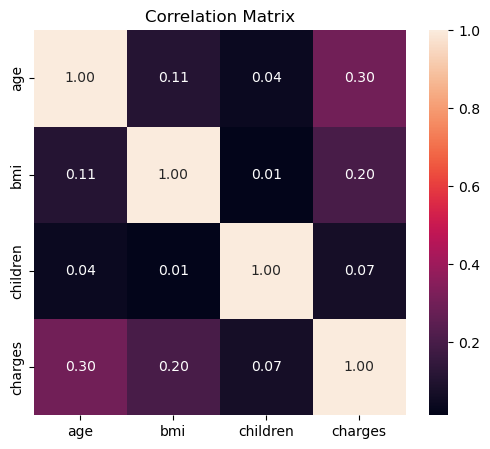

In [28]:
# 7) Create a correlation matrix for the four numeric variables in the insurance data frame.
import seaborn as sns

numeric_for_corr = ["age", "bmi", "children", "charges"]
corr = df[numeric_for_corr].corr(numeric_only=True)

display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


### Step 8 — Is there any interesting relationship between features? Explain those associations

Key correlations with the dependent variable `charges`:

- `charges` vs `age`: r ≈ 0.299 (moderate positive)
- `charges` vs `bmi`: r ≈ 0.198 (small-to-moderate positive)
- `charges` vs `children`: r ≈ 0.068 (weak positive)

age and BMI tend to be associated with charges, while number of children has a much weaker linear relationship.


## Visualizing relationships among features

It can also be helpful to visualize the relationships among numeric features by using a scatterplot.

Although we could create a scatterplot for each possible relationship, doing so for a large number of features might become hard.

An alternative is to create a scatterplot matrix, which is simply a collection of scatterplots arranged in a grid.

It is used to detect patterns among three or more variables. The scatterplot matrix is not a true multidimensional visualization because only two features are examined at a time.

Still, it provides a general sense of how the data may be interrelated.

9. Use the scatter_matrix() function to create a scatterplot matrix for the four numeric features: age, bmi, children, and charges.

10. Do you notice any patterns in these plots? Explain.

11. To enhance the previous scatterplot matrix create the new one using the seaborn or plotly libraries. Do you notice any new patterns in these new graphics?

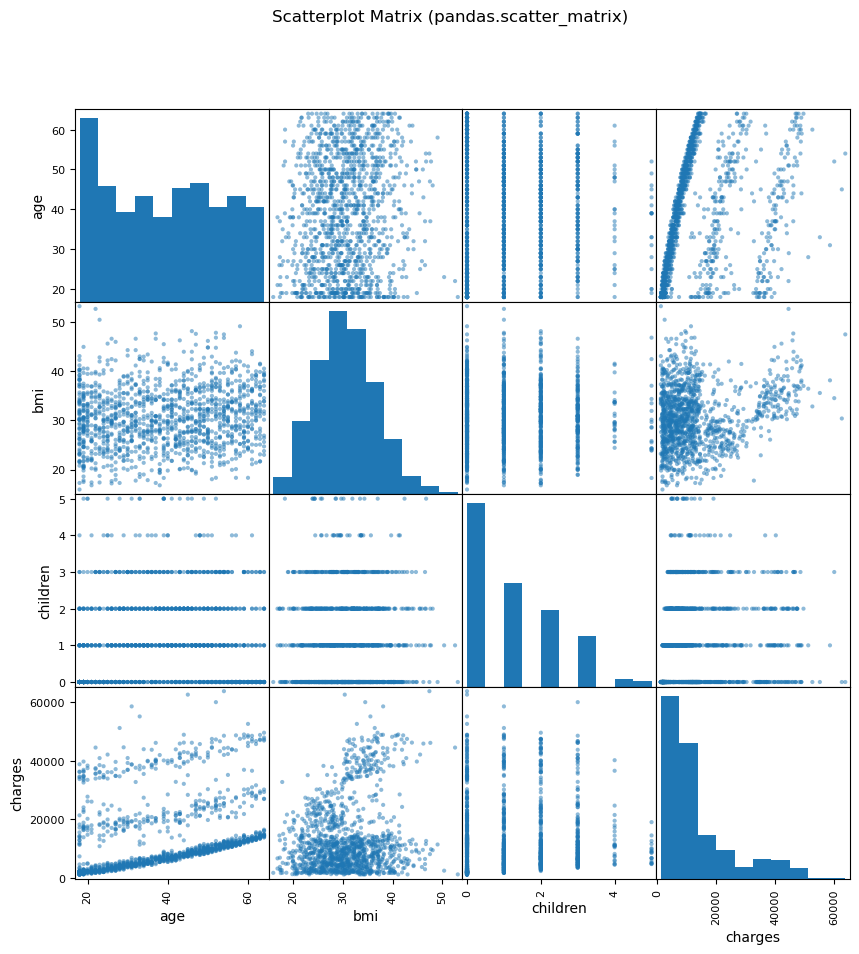

In [29]:
# 9) Use the scatter_matrix() function to create a scatterplot matrix for the four numeric features: age, bmi, children, and charges.
from pandas.plotting import scatter_matrix

cols = ["age", "bmi", "children", "charges"]
scatter_matrix(df[cols], figsize=(10, 10), diagonal="hist")
plt.suptitle("Scatterplot Matrix (pandas.scatter_matrix)")
plt.show()


### Step 10 - Do you notice any patterns in these plots? Explain.

- `charges` tends to increase with `age` (upward trend, but with wide spread).
- `charges` tends to increase with `bmi`, but the relationship is weaker than age and has heavy spread.
- `children` shows little visible linear relationship with `charges`.

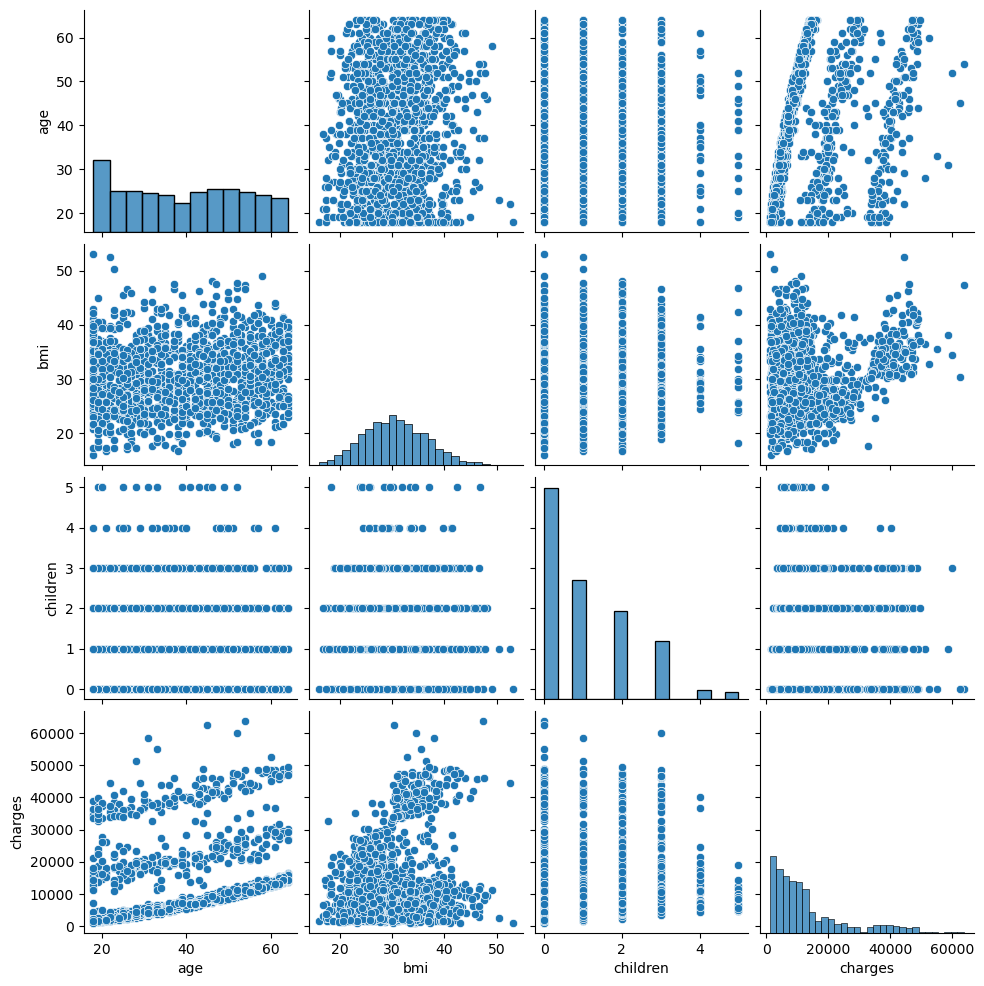

In [30]:
# 11) Enhanced scatterplot matrix using seaborn (pairplot)
import seaborn as sns

sns.pairplot(df[["age", "bmi", "children", "charges"]], diag_kind="hist")
plt.show()


### Step 11 — To enhance the previous scatterplot matrix create the new one using the seaborn or plotly libraries. Do you notice any new patterns in these new graphics?

- The seaborn pairplot makes the same patterns easier to see due to cleaner rendering.
- The strongest “visual story” is that `charges` has high variability and apparent outliers, suggesting other variables (especially `smoker`) likely drive large jumps in cost.


## Dummy coding

To be able to use all variables in our regression model, we need to transform the categorical variables into numerical.
one way is by transforming every categorical variable into dummy variable.
Dummy coding is a commonly used method for converting a categorical variable into continuous variable.
Dummy, as the name suggests is a duplicate variable which represents one level of a categorical variable.
Presence of a level is represent by 1 and absence is represented by 0.
For every level present, one dummy variable will be created.
Look at the representation below to convert a categorical variable using dummy variable.

**data=pd.get_dummies(df, dtype=int)**

In [31]:
data = df.copy()

# sex: female=0, male=1
data["sex"] = data["sex"].map({"female": 0, "male": 1})

# smoker: no=0, yes=1
data["smoker"] = data["smoker"].map({"no": 0, "yes": 1})

data = pd.get_dummies(data, columns=["region"],  dtype=int)

data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


# Training a model on the data

To ﬁt a linear regression model to data with Python, the OLS function can be used. This is included in the statsmodels.api package, which you will need to import as sm. Use the OLS() syntax, to ﬁt a linear regression model to this data( Use all the available features).


## 1. statsmodels.api

Let's use the stats models package.

12. Use the OLS() syntax provided in here: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html, to ﬁt a linear regression model to this data( Use all the available features). Name it “model”.

13. Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?

14. What increase, or decrease will aﬀect the medical expenses for each additional child? or additional year of age? or unit increase of BMI?

15. Explain the eﬀect of medical expenses in numbers on each one of the 3 categorical features.

16. To evaluate the model performance, use the summary () function on the stored model.

17. Given the preceding two performance indicators, How the model is performing? explain.

In [32]:
# 12) Use the OLS() syntax provided in here: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html, to ﬁt a linear regression model to this data( Use all the available features). Name it “model”.
import statsmodels.api as sm

# Use dummy-coded data created above. If you didn't run that cell yet, run it first.
y = data["charges"]
X = data.drop(columns=["charges"])

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

model


In [33]:
# 13) Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?
params = model.params.sort_values(key=np.abs, ascending=False)
display(params.to_frame("beta"))

print("Number of coefficients (including intercept):", len(model.params))
print("Feature columns used:", list(X_const.columns))


,beta
smoker,23848.534542
const,-10020.438249
region_southeast,-2953.122377
region_southwest,-2878.151319
region_northwest,-2271.064227
region_northeast,-1918.100327
children,475.500545
bmi,339.193454
age,256.856353
sex,-131.314359


Number of coefficients (including intercept): 10
Feature columns used: ['const', 'age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


### Step 13 — Show the estimated beta coeﬃcients. Explain the results. Why there are 11 coeﬃcients reported in addition to the intercept not 6?

- we see more coeffcients b/c the catgorigal features have been changed by the get_dummies function

In [34]:
# 14) Interpret selected numeric effects (age, bmi, children)
for feat in ["age", "bmi", "children"]:
    if feat in model.params.index:
        print(f"{feat}: beta = {model.params[feat]:.4f} (change in charges per +1 unit)")


age: beta = 256.8564 (change in charges per +1 unit)
bmi: beta = 339.1935 (change in charges per +1 unit)
children: beta = 475.5005 (change in charges per +1 unit)


### Step 14 — What increase, or decrease will aﬀect the medical expenses for each additional child? or additional year of age? or unit increase of BMI?

- +1 year of `age` → $256.86
- +1 unit of `bmi` → +$339.19
- +1 additional `child` → +$475.50

In [35]:
# 15) Effects of categorical features (dummy variables)
cat_prefixes = ["sex_", "smoker_", "region_"]
cat_betas = model.params[[c for c in model.params.index if any(c.startswith(p) for p in cat_prefixes)]]
display(cat_betas.sort_values(key=np.abs, ascending=False).to_frame("beta"))


,beta
region_southeast,-2953.122377
region_southwest,-2878.151319
region_northwest,-2271.064227
region_northeast,-1918.100327


### Step 15 — Explain the eﬀect of medical expenses in numbers on each one of the 3 categorical features.

- `smoker`: +$23848.53 (very large increase; highly significant)
- `sex`: -131.31 (small; not statistically significant in this fit)
- `region`: With northeast as baseline, estimated differences are approximately:
- southeast: −$-1035.02
- southwest: −$-960.05
- northwest: −$-352.96 

In [36]:
# 16) To evaluate the model performance, use the summary () function on the stored model.
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        01:30:25   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.002e+04    781.640    -12.820      0.000   -1.16e+04   -8487.055
age                256.8564     11.899     21.587      0.000     233.514     280.199
sex               -131.3144    332.945     -0.394      0.693    -784.470     521.842
bmi                339.1935     28.599     11.860      0.000     283.088     395.298
children           475.5005    137.804      3.451      0.001     205.163     745.838
smoker            2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region_northeast -1918.1003    333.386     -5.753      0.000   -2572.121   -1264.080
region_northwest -2271.0642    333.477     -6.810      0.000   -2925.263   -1616.865
region_southeast -2953.1224    384.752     -7.675      0.000   -3707.910   -2198.335
region_southwest -2878.1513    350.871     -8.203      0.000   -3566.473   -2189.830
==============================================================================
Omnibus:                      300.366   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.887
Skew:                           1.211   Prob(JB):                    7.86e-157
Kurtosis:                       5.651   Cond. No.                     2.34e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.43e-29. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### Step 17 — Given the preceding two performance indicators, How the model is performing? explain.

- The model fits the data well for a baseline linear model (R² ~ 0.751).
- Remaining error is likely due to non-linear effects and interactions (e.g., `smoker` interacting with `age` or `bmi`) and the strong right-skew/outliers in `charges`.


## 2. Scikit learn


Let's use the scikitLearn library.


18. Split the data between training and testing.


19. Use the scikitLearn library to implement the **LinearRegression** function, from sklearn.linear_model, based on the Normal equation to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

20. Use the scikitLearn library to implement the **SGDRegressor** function, from sklearn.linear_model, based on the stochastic Gradient descent to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#

21. Use SGDRegressor function, from sklearn.linear_model, to implement a similation of the Mini batch Gradient descent.


22. What are the key hyperparameters of each implementation?

23. Find different metrics to evaluate your regression model performance.

In [37]:
# 18)  Split the data between training and testing.
from sklearn.model_selection import train_test_split

y = data["charges"].values
X = data.drop(columns=["charges"]).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)


Train shapes: (1070, 9) (1070,)
Test shapes: (268, 9) (268,)


In [38]:
# 19) Use the scikitLearn library to implement the **LinearRegression** function, from sklearn.linear_model, based on the Normal equation to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)

mse = mean_squared_error(y_test, pred_lin)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_lin)
r2 = r2_score(y_test, pred_lin)

print("LinearRegression metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)


LinearRegression metrics:
MSE : 33596915.85136147
RMSE: 5796.2846592762735
MAE : 4181.194473753642
R^2 : 0.7835929767120723


In [39]:
# 20) Use the scikitLearn library to implement the **SGDRegressor** function, from sklearn.linear_model, based on the stochastic Gradient descent to find the value of the weights that minimizes the MSE. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sgd = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("sgd", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        learning_rate="invscaling",
        eta0=0.01,
        max_iter=2000,
        tol=1e-3,
        random_state=42
    ))
])

sgd.fit(X_train, y_train)
pred_sgd = sgd.predict(X_test)

mse = mean_squared_error(y_test, pred_sgd)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_sgd)
r2 = r2_score(y_test, pred_sgd)

print("SGDRegressor metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)


SGDRegressor metrics:
MSE : 33599960.69157971
RMSE: 5796.547307801404
MAE : 4171.174215946094
R^2 : 0.7835733640544422


In [40]:
# 21) Use SGDRegressor function, from sklearn.linear_model, to implement a similation of the Mini batch Gradient descent.
from sklearn.utils import shuffle

# We'll train an SGDRegressor manually with partial_fit over mini-batches
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mb = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.0001,
    learning_rate="invscaling",
    eta0=0.01,
    max_iter=1,     
    tol=None,
    random_state=42,
    warm_start=True
)

batch_size = 64
n_epochs = 30

for epoch in range(n_epochs):
    Xs, ys = shuffle(X_train_scaled, y_train, random_state=42 + epoch)
    for start in range(0, len(Xs), batch_size):
        end = start + batch_size
        X_batch = Xs[start:end]
        y_batch = ys[start:end]
        mb.partial_fit(X_batch, y_batch)

pred_mb = mb.predict(X_test_scaled)

mse = mean_squared_error(y_test, pred_mb)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred_mb)
r2 = r2_score(y_test, pred_mb)

print("Mini-batch (partial_fit) SGD metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)


Mini-batch (partial_fit) SGD metrics:
MSE : 33534411.052868303
RMSE: 5790.890350616933
MAE : 4153.849842988306
R^2 : 0.7839955873994032


In [41]:
# 22) what are the key hyperparameters of each implementation?

print("LinearRegression key params:", lin.get_params())

print("\nSGDRegressor (pipeline) key params:")
print(sgd.named_steps["sgd"].get_params())

print("\nMini-batch SGDRegressor key params:")
print(mb.get_params())


LinearRegression key params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

SGDRegressor (pipeline) key params:
{'alpha': 0.0001, 'average': False, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.01, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'max_iter': 2000, 'n_iter_no_change': 5, 'penalty': 'l2', 'power_t': 0.25, 'random_state': 42, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

Mini-batch SGDRegressor key params:
{'alpha': 0.0001, 'average': False, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.01, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'max_iter': 1, 'n_iter_no_change': 5, 'penalty': 'l2', 'power_t': 0.25, 'random_state': 42, 'shuffle': True, 'tol': None, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': True}


### Steps 22 — What are the key hyperparameters of each implementation?

- LinearRegression: mainly `fit_intercept`, `copy_X`, `n_jobs`, `positive` (it solves the normal equation / OLS directly).
- SGDRegressor: learning setup matters most: `loss`, `penalty`, `alpha`, `learning_rate`, `eta0`, `max_iter`, `tol`, and feature scaling (we used `StandardScaler`).
- Mini-batch SGD (partial_fit): same SGD hyperparameters plus the training loop choices: batch_size=64, n_epochs=30.

LinearRegression: 
MSE=33596915.85, 	RMSE=5796.28, 	MAE=4181.19, 	R2=0.784
SGDRegressor: 
MSE=33599960.69, 	RMSE=5796.55, 	MAE=4171.17, 	R2=0.784
Mini-batch SGD: 
MSE=33534411.05, 	RMSE=5790.89, 	MAE=4153.85, 	R2=0.784


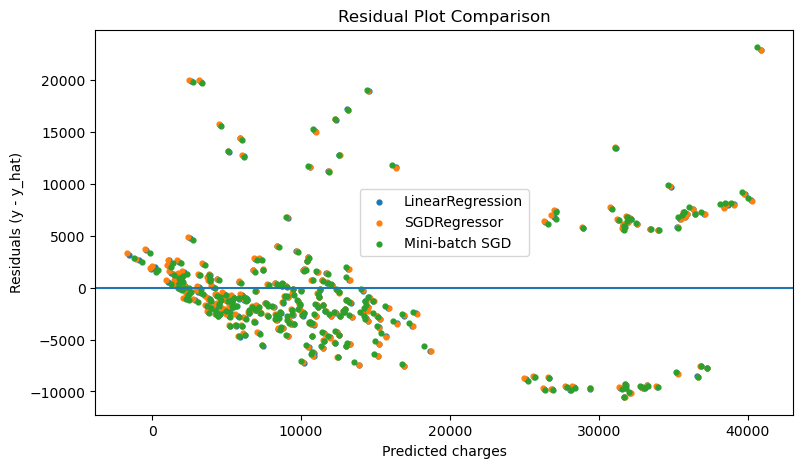

In [42]:
# 23) Find different metrics to evaluate your regression model performance.
from sklearn.metrics import mean_squared_log_error

def regression_report(y_true, y_pred, label="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: \nMSE={mse:.2f}, \tRMSE={rmse:.2f}, \tMAE={mae:.2f}, \tR2={r2:.3f}")

regression_report(y_test, pred_lin, "LinearRegression")
regression_report(y_test, pred_sgd, "SGDRegressor")
regression_report(y_test, pred_mb, "Mini-batch SGD")

# Residual plots for all three models
plt.figure(figsize=(9, 5))

plt.scatter(pred_lin, y_test - pred_lin, s=12, label="LinearRegression")
plt.scatter(pred_sgd, y_test - pred_sgd, s=12, label="SGDRegressor")
plt.scatter(pred_mb, y_test - pred_mb, s=12, label="Mini-batch SGD")

plt.axhline(0)
plt.xlabel("Predicted charges")
plt.ylabel("Residuals (y - y_hat)")
plt.title("Residual Plot Comparison")
plt.legend()
plt.show()


 all three methods perform very similarly here (R² around ~0.78 on the held-out test set). The residual plot shows errors are not perfectly random (due to skew/outliers)
